# Regresión — explorar datos y entrenar un modelo base

Las técnicas de **aprendizaje supervisado** entrenan un modelo sobre un conjunto de *features* para predecir un *label*, usando datos donde el label ya se conoce. El entrenamiento *ajusta* las features a los labels conocidos para definir una función general que después se aplica a features nuevas:

> f(x) = y

Como normalmente `x` es un **vector** de varias features, con más precisión sería:

> f([x1, x2, x3, ...]) = y

En este cuaderno trabajamos con **regresión**, sobre un caso real: datos de un sistema de alquiler de bicicletas, para predecir el número de alquileres según la estación del año y las condiciones meteorológicas.

## Cargar los datos

El primer paso de cualquier proyecto de ML es explorar los datos. El objetivo es entender las relaciones entre sus atributos, en especial la correlación entre las features y el label que se quiere predecir.

El dataset ya está en `../datasets/daily-bike-share.csv`.

> **Cita**: los datos provienen de [Capital Bikeshare](https://www.capitalbikeshare.com/system-data) y se usan según su [acuerdo de licencia](https://www.capitalbikeshare.com/data-license-agreement).

In [1]:
import pandas as pd

# Cargar el dataset de entrenamiento
bike_data = pd.read_csv('../datasets/daily-bike-share.csv')
bike_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82


Las columnas son:

| Columna | Significado |
|---|---|
| **instant** | Identificador único de fila |
| **dteday** | Fecha de la observación (una fila por día) |
| **season** | Estación codificada (1: invierno, 2: primavera, 3: verano, 4: otoño) |
| **yr** | Año del estudio (0 = 2011, 1 = 2012) |
| **mnth** | Mes (1: enero … 12: diciembre) |
| **holiday** | Binario: ¿era festivo? |
| **weekday** | Día de la semana (0: domingo … 6: sábado) |
| **workingday** | Binario: ¿era día laborable? |
| **weathersit** | Clima (1: despejado, 2: niebla/nubes, 3: lluvia/nieve ligera, 4: lluvia fuerte/granizo) |
| **temp** | Temperatura en °C (normalizada) |
| **atemp** | Temperatura aparente ("sensación térmica"), normalizada |
| **hum** | Humedad (normalizada) |
| **windspeed** | Velocidad del viento (normalizada) |
| **rentals** | Número de alquileres registrados |

**`rentals` es el label** (el valor `y` que queremos predecir). El resto son features candidatas (`x`).

### Ingeniería de características

Se pueden derivar features nuevas a partir de las existentes — eso se llama *feature engineering*. Por ejemplo, extraer el día del mes de la columna `dteday`:

In [2]:
bike_data['day'] = pd.DatetimeIndex(bike_data['dteday']).day
bike_data.head(32)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals,day
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,1
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,2
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,3
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,4
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,5
5,6,1/6/2011,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,6
6,7,1/7/2011,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,7
7,8,1/8/2011,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,8
8,9,1/9/2011,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,9
9,10,1/10/2011,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,10


## Perfilamiento: estadística descriptiva

Empecemos con `describe()` sobre las features numéricas y el label.

In [3]:
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
bike_data[numeric_features + ['rentals']].describe()

,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471
std,0.183051,0.162961,0.142429,0.077498,686.622488
min,0.059130,0.079070,0.000000,0.022392,2.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000
50%,0.498333,0.486733,0.626667,0.180975,713.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000


Esto revela la distribución de cada campo numérico: número de observaciones (731 registros), media, desviación estándar, mínimo, máximo y los cuartiles.

Se ve que la media de alquileres diarios ronda los **848**, pero con una desviación estándar comparativamente grande — hay mucha variación de un día a otro.

Para entender mejor esa distribución, la visualizamos con un histograma y un diagrama de caja.

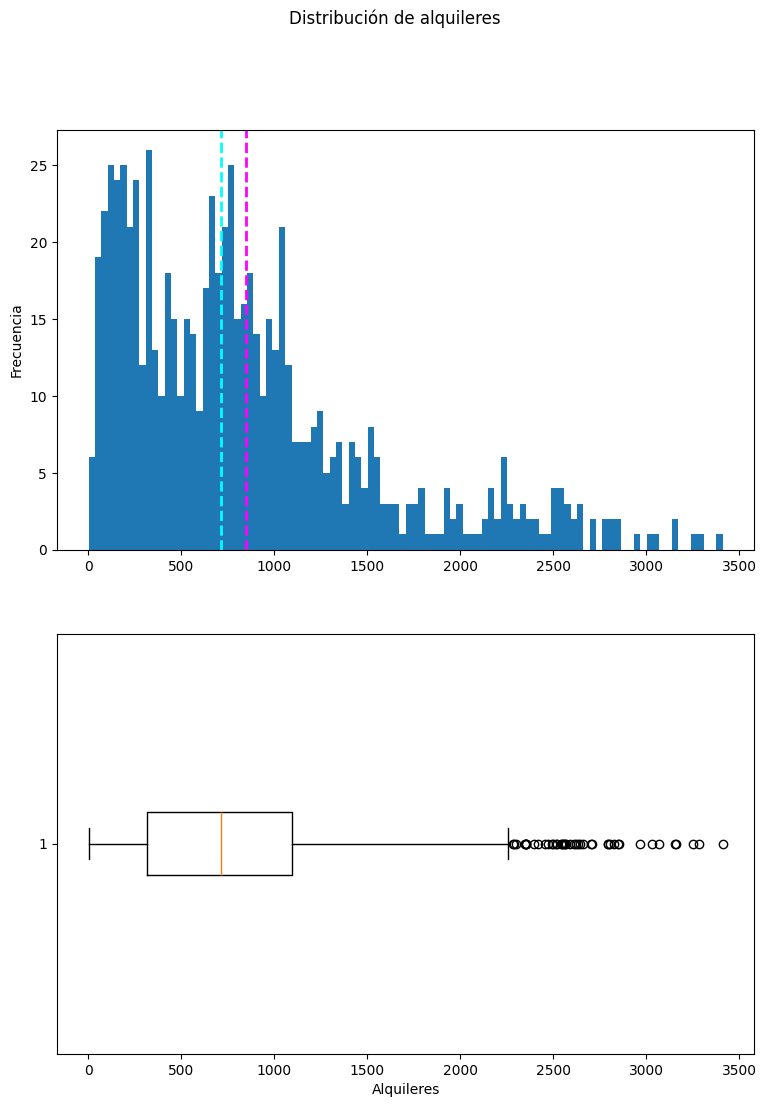

In [4]:
import matplotlib.pyplot as plt

label = bike_data['rentals']

# Figura con 2 subgráficos (2 filas, 1 columna)
fig, ax = plt.subplots(2, 1, figsize=(9, 12))

# Histograma
ax[0].hist(label, bins=100)
ax[0].set_ylabel('Frecuencia')

# Líneas para media y mediana
ax[0].axvline(label.mean(), color='magenta', linestyle='dashed', linewidth=2)
ax[0].axvline(label.median(), color='cyan', linestyle='dashed', linewidth=2)

# Diagrama de caja
ax[1].boxplot(label, vert=False)
ax[1].set_xlabel('Alquileres')

fig.suptitle('Distribución de alquileres')
plt.show()

Los alquileres diarios van de 0 a algo más de 3.400. Pero la media (y la mediana) están cerca del extremo bajo del rango, con la mayoría de los datos entre 0 y unos 2.200.

Los pocos valores por encima aparecen en el diagrama de caja como círculos sueltos: son **valores atípicos**.

Hagamos la misma exploración visual con las features numéricas.

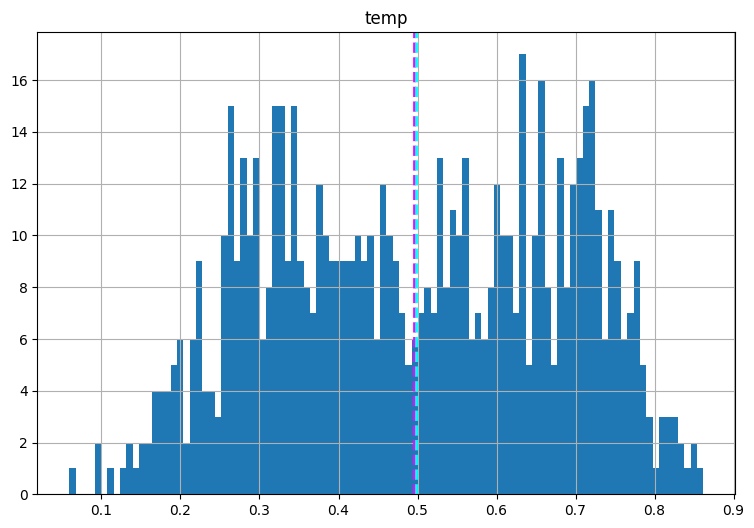

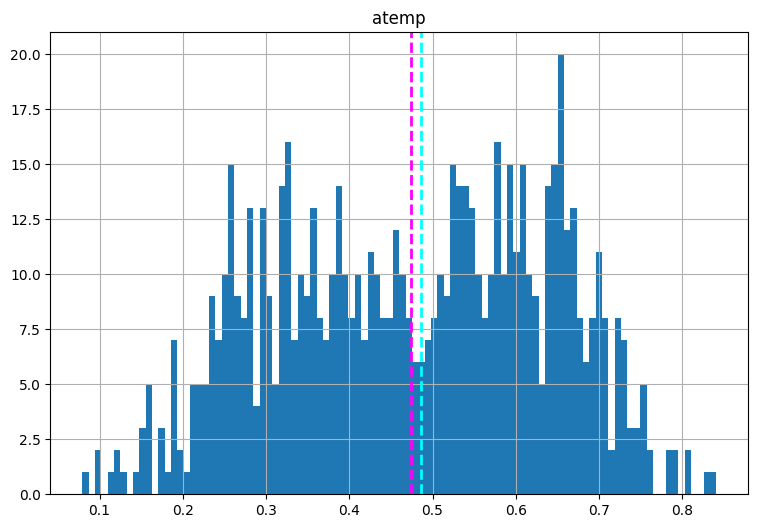

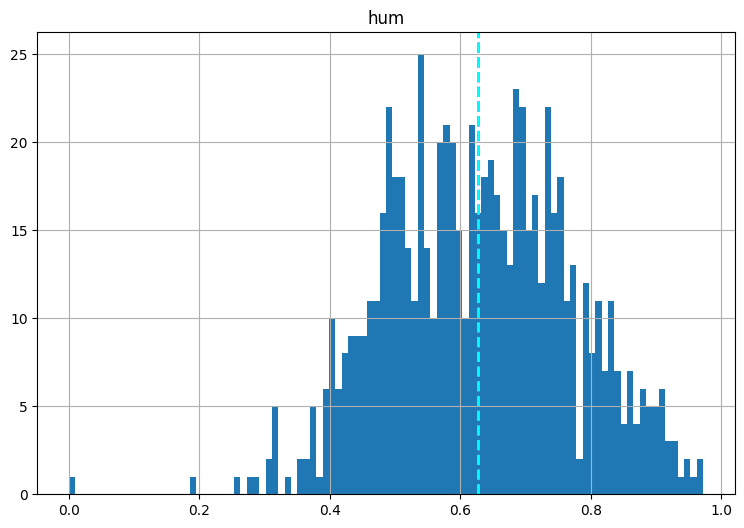

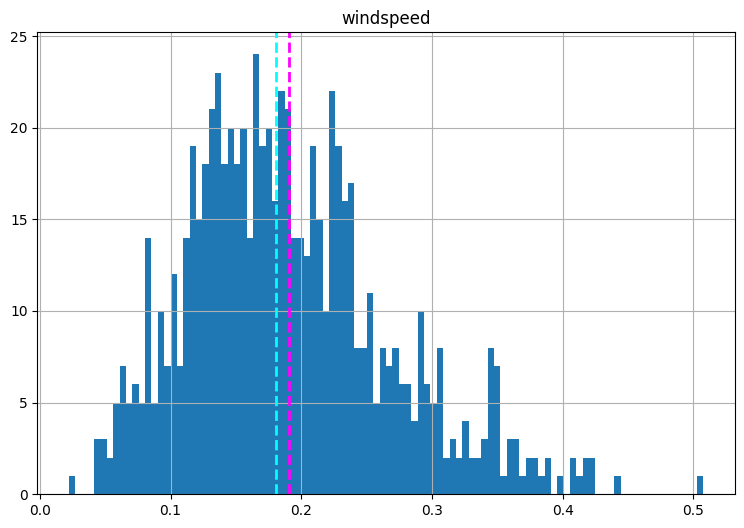

In [5]:
# Histograma de cada feature numérica
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = bike_data[col]
    feature.hist(bins=100, ax=ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
plt.show()

Las features numéricas se ven más *normalmente* distribuidas: media y mediana cerca del centro del rango, coincidiendo con los valores más frecuentes.

> **Nota**: no son normales en sentido estricto (eso daría una campana perfectamente simétrica), pero sí indican que la mayoría de las observaciones caen cerca del medio.

¿Y las features **categóricas**? No son números continuos en una escala, así que un histograma no aplica. En su lugar, un gráfico de barras con el conteo de cada valor discreto.

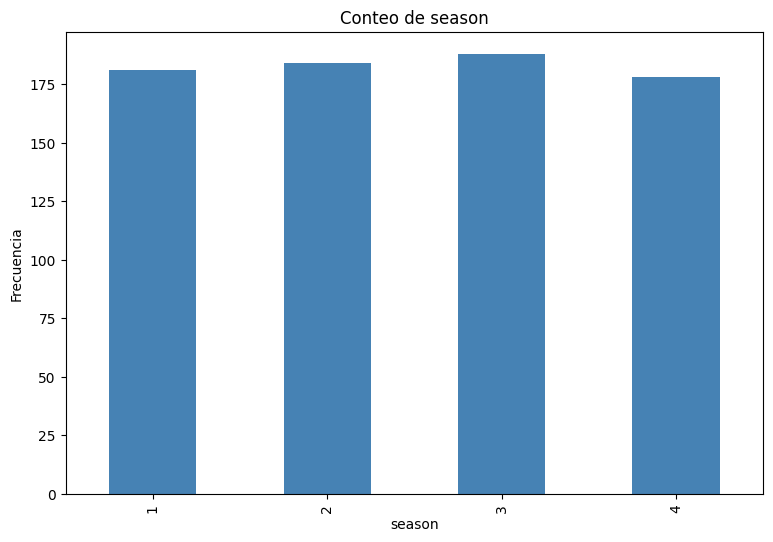

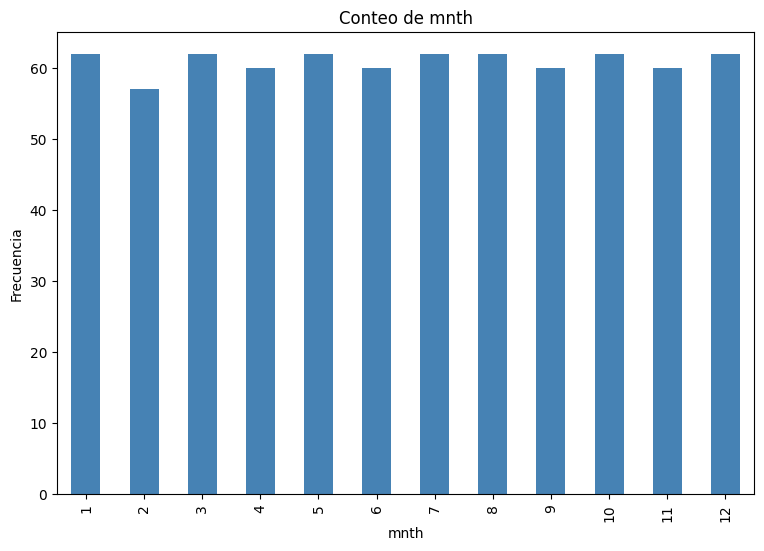

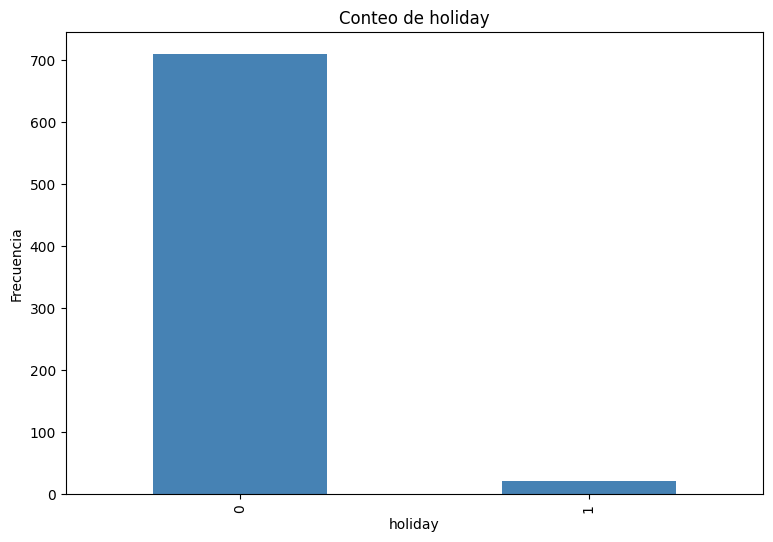

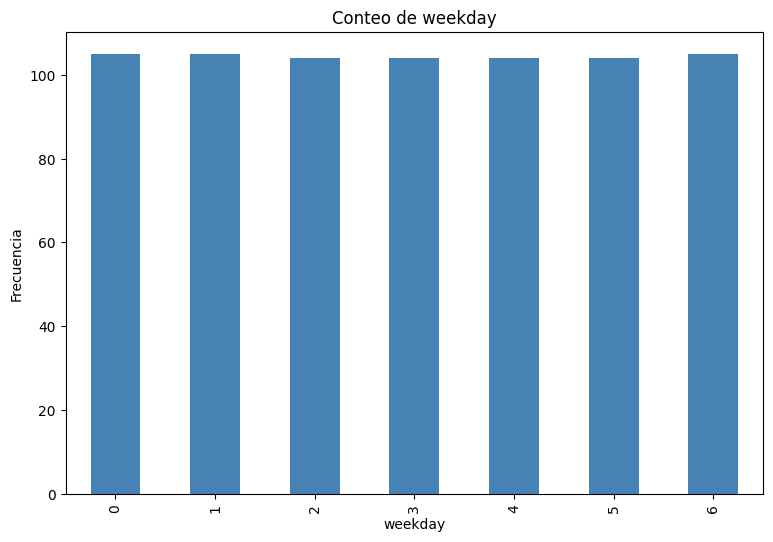

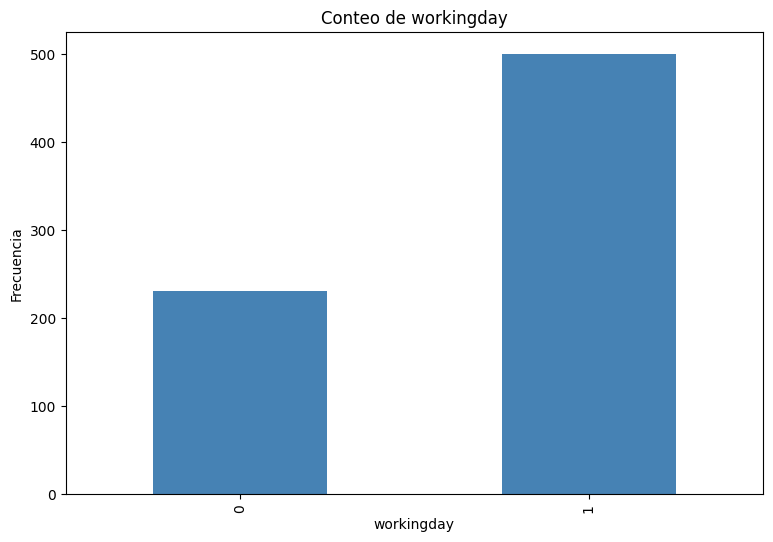

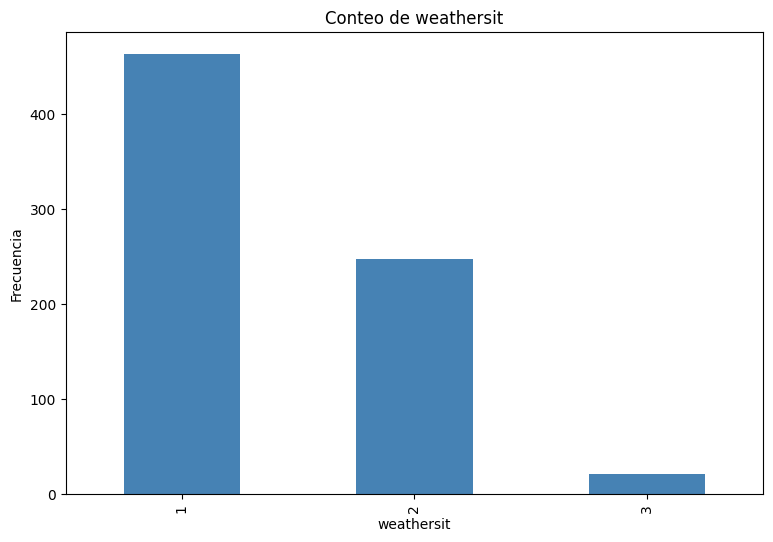

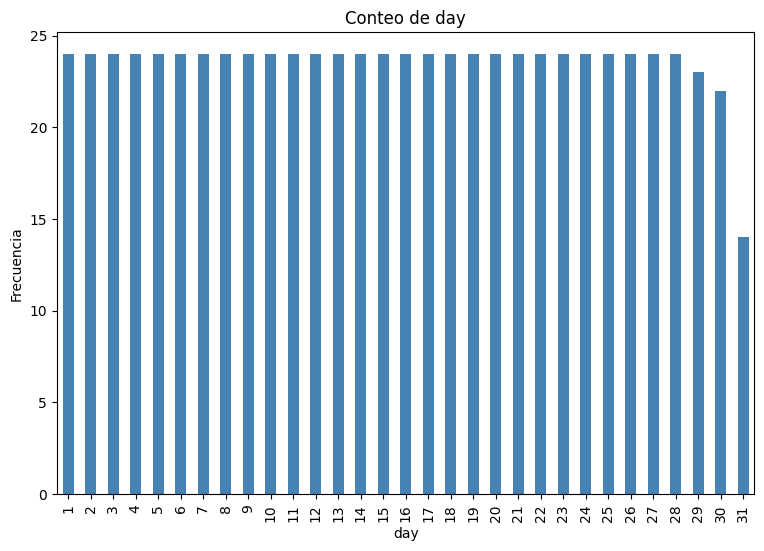

In [6]:
categorical_features = ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'day']

for col in categorical_features:
    counts = bike_data[col].value_counts().sort_index()
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    counts.plot.bar(ax=ax, color='steelblue')
    ax.set_title(f'Conteo de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
plt.show()

La mayoría de las categóricas tienen distribución más o menos **uniforme** (aproximadamente el mismo número de filas por categoría). Las excepciones:

- **holiday**: hay muchos menos días festivos que no festivos.
- **workingday**: hay más días laborables que no laborables.
- **weathersit**: casi todos los días son categoría *1* (despejado), seguida de *2* (niebla/nubes). Hay pocos de categoría *3* y **ninguno** de categoría *4*.

## Buscar relaciones entre features y label

Ya sabemos cómo se distribuye cada columna. Ahora toca buscar **relaciones** con el label.

Para las numéricas, un diagrama de dispersión más el valor de correlación.

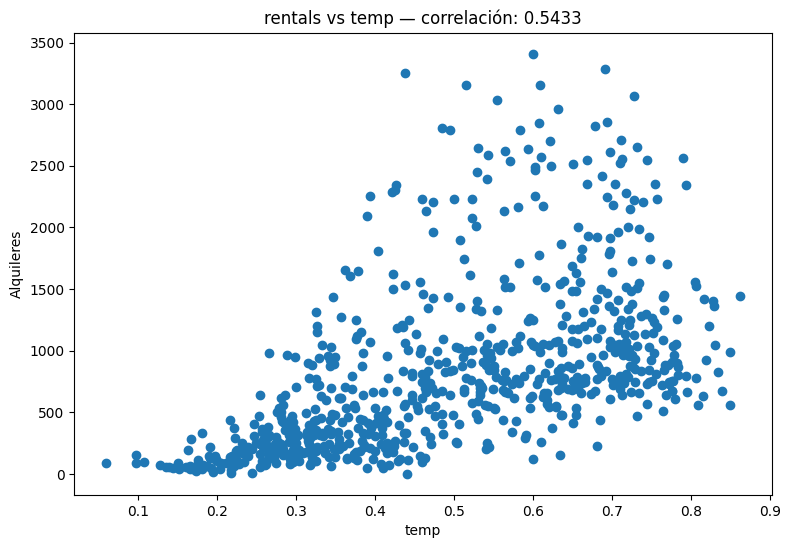

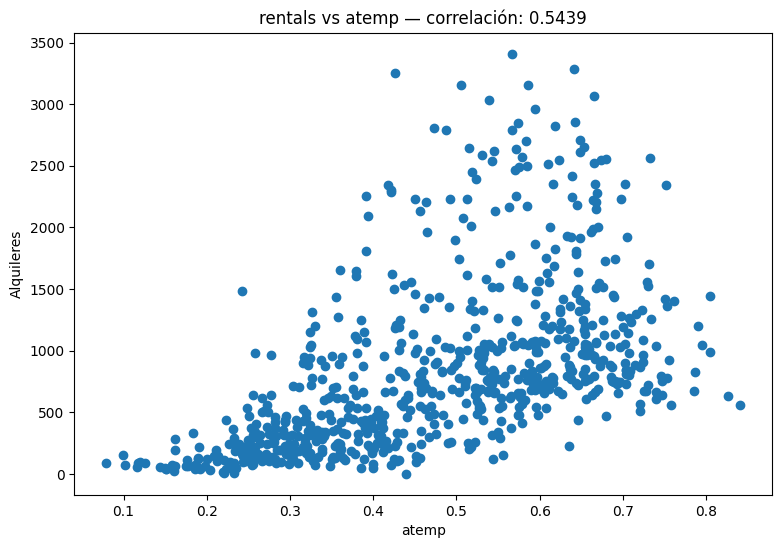

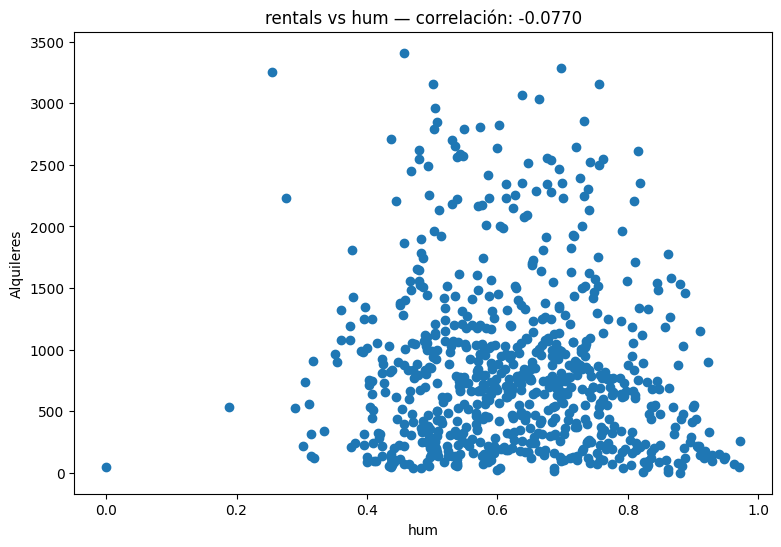

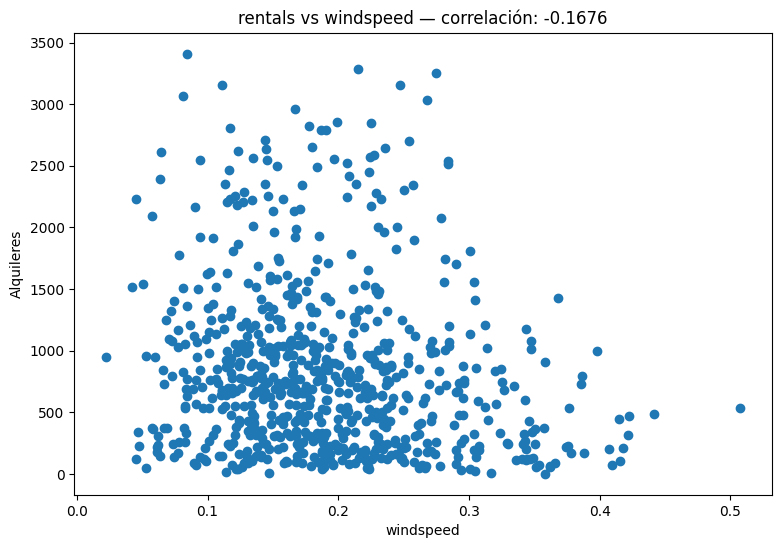

In [7]:
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = bike_data[col]
    label = bike_data['rentals']
    correlation = feature.corr(label)
    plt.scatter(x=feature, y=label)
    plt.xlabel(col)
    plt.ylabel('Alquileres')
    ax.set_title(f'rentals vs {col} — correlación: {correlation:.4f}')
plt.show()

Los resultados no son concluyentes, pero mirando de cerca `temp` y `atemp` se ve una tendencia diagonal difusa: más alquileres coinciden con temperaturas más altas, y una correlación de algo más de 0.5 en ambas respalda esa observación.

Al contrario, `hum` y `windspeed` muestran correlación ligeramente **negativa**: hay menos alquileres en días de mucha humedad o viento.

Ahora comparemos las categóricas contra el label, con diagramas de caja.

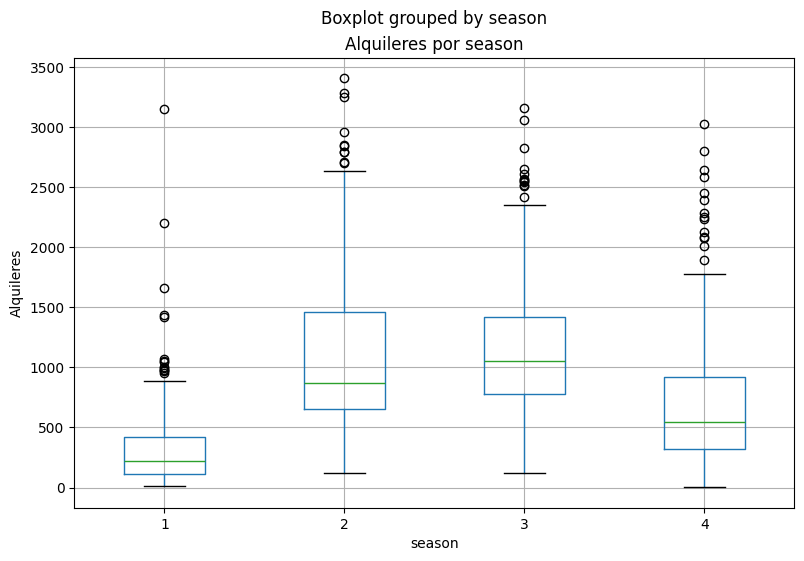

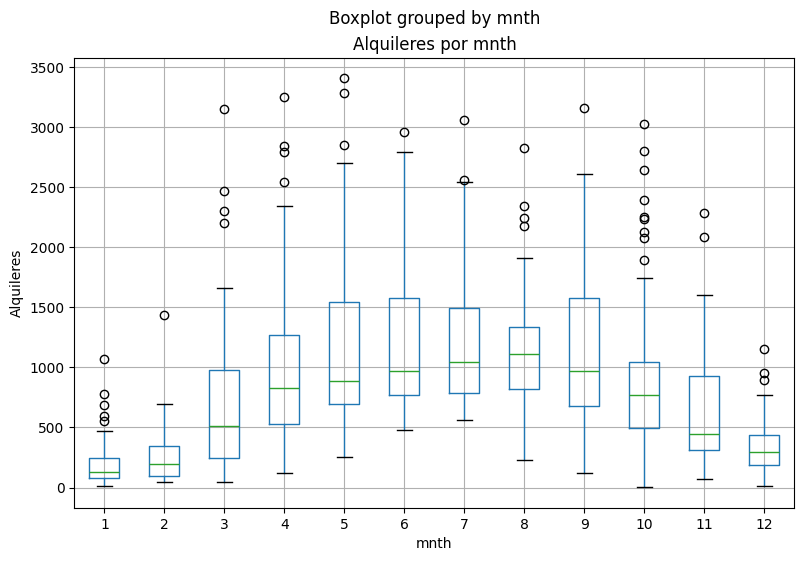

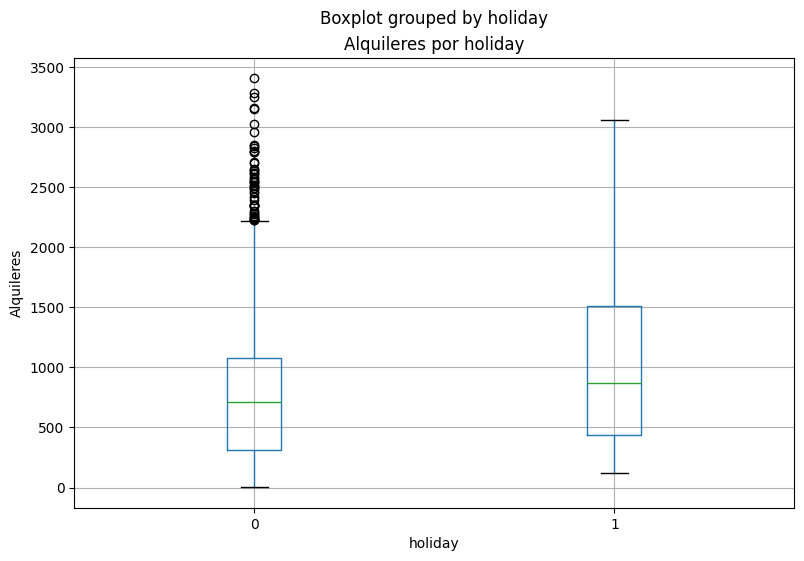

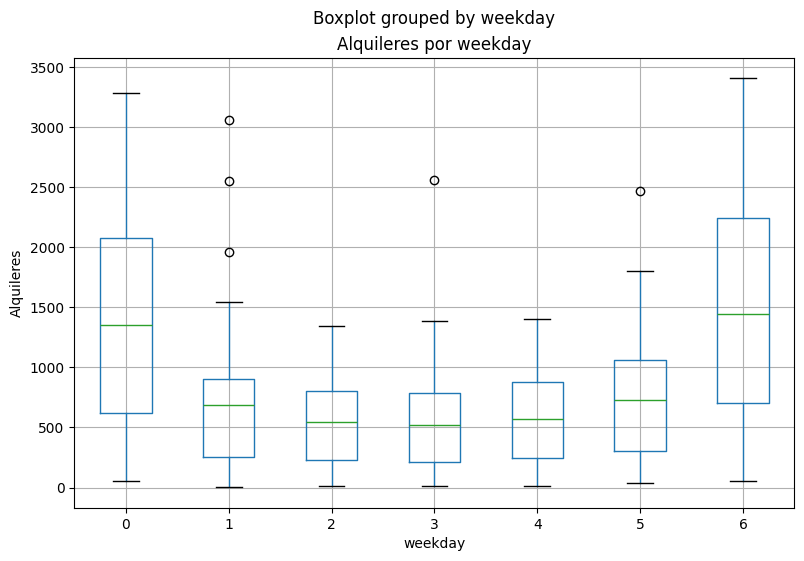

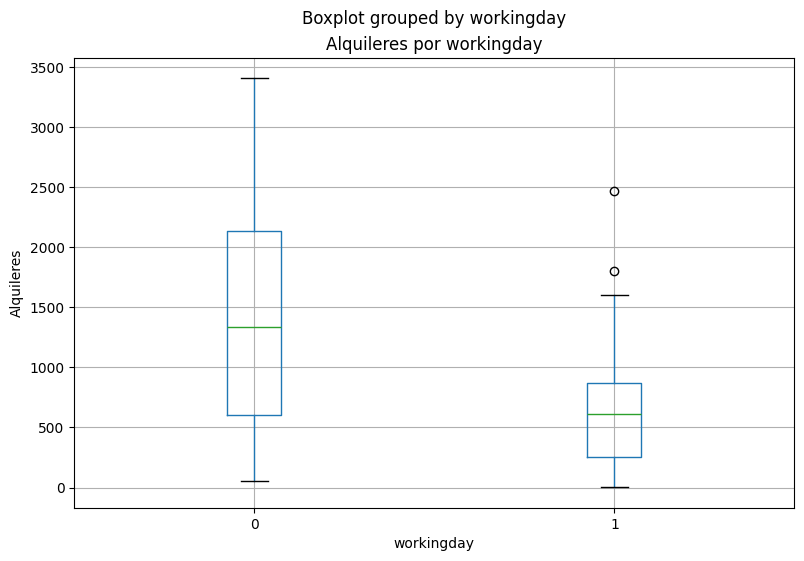

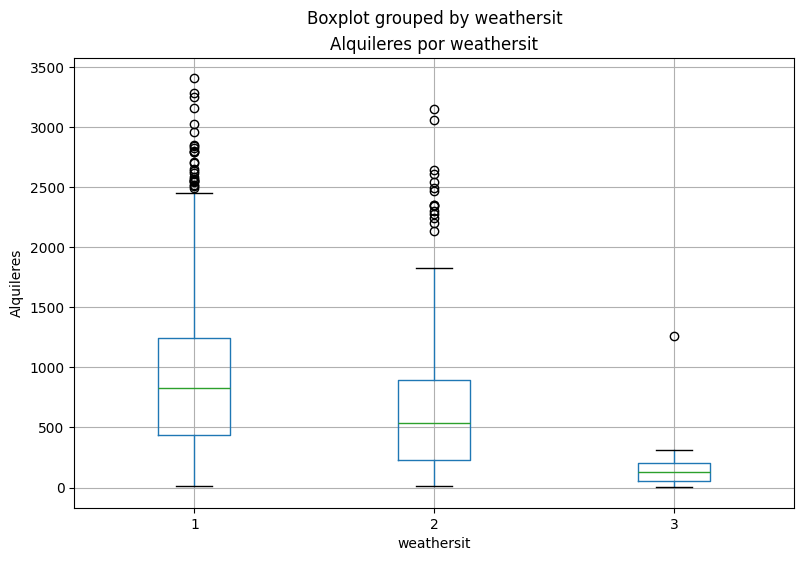

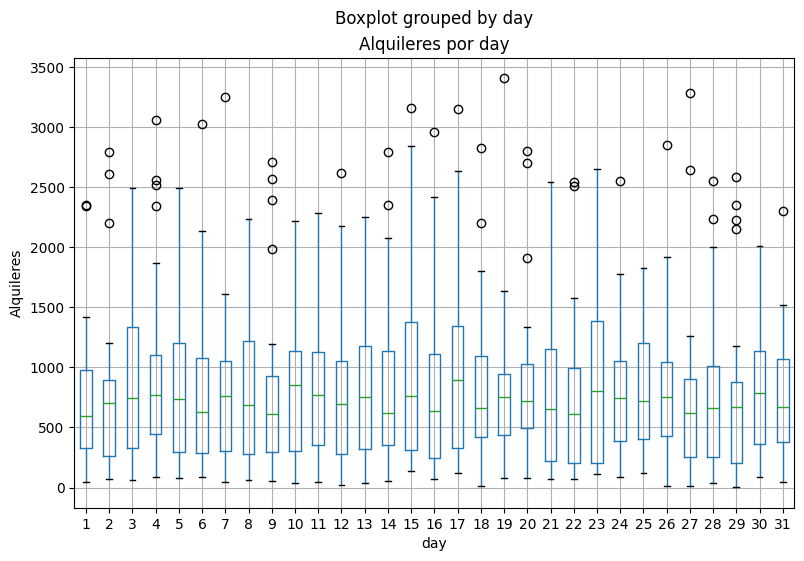

In [8]:
# Diagrama de caja del label por cada feature categórica
for col in categorical_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    bike_data.boxplot(column='rentals', by=col, ax=ax)
    ax.set_title(f'Alquileres por {col}')
    ax.set_ylabel('Alquileres')
plt.show()

Hay variación clara en algunas categorías:

- Diferencia marcada entre fines de semana (`weekday` 0 o 6) y días de la semana laboral (1 a 5).
- Lo mismo para `holiday` y `workingday`.
- Tendencia notable entre primavera/verano frente a otoño/invierno.
- `weathersit` también marca diferencia.
- **`day` (el día del mes que creamos) apenas varía** → probablemente no sea predictivo. Buen ejemplo de que derivar una feature no garantiza que sirva.

## Entrenar el modelo

Primero, separar las features del label.

In [9]:
# Separar features y labels
X, y = bike_data[['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
                  'temp', 'atemp', 'hum', 'windspeed']].values, bike_data['rentals'].values

print('Features:', X[:5], '\nLabels:', y[:5], sep='\n')

Features:
[[1.       1.       0.       6.       0.       2.       0.344167 0.363625
  0.805833 0.160446]
 [1.       1.       0.       0.       0.       2.       0.363478 0.353739
  0.696087 0.248539]
 [1.       1.       0.       1.       1.       1.       0.196364 0.189405
  0.437273 0.248309]
 [1.       1.       0.       2.       1.       1.       0.2      0.212122
  0.590435 0.160296]
 [1.       1.       0.       3.       1.       1.       0.226957 0.22927
  0.436957 0.1869  ]]

Labels:
[331 131 120 108  82]


Ahora tenemos dos arrays de NumPy: **X** con las features y **y** con los labels.

*Podríamos* entrenar con todos los datos, pero lo estándar es dividirlos: un conjunto (normalmente mayor) para entrenar, y otro reservado para validar.

Es importante que la división sea **aleatoria** (no "el primer 70% para entrenar"). Así ambos subconjuntos son estadísticamente comparables, y validamos con datos cuya distribución se parece a la de entrenamiento.

In [10]:
from sklearn.model_selection import train_test_split

# División 70% / 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} filas')
print(f'Conjunto de prueba:        {X_test.shape[0]} filas')

Conjunto de entrenamiento: 511 filas
Conjunto de prueba:        220 filas


Quedan cuatro conjuntos:

- **X_train** / **y_train** → para entrenar
- **X_test** / **y_test** → para validar

En scikit-learn los algoritmos de entrenamiento se encapsulan en *estimadores*. Usaremos **LinearRegression**, que busca una relación lineal entre los valores de `X` y el label `y`.

Este será nuestro **modelo base (baseline)**: el punto de comparación contra el que mediremos cualquier mejora posterior.

In [11]:
from sklearn.linear_model import LinearRegression

# Ajustar un modelo de regresión lineal sobre el conjunto de entrenamiento
model = LinearRegression().fit(X_train, y_train)
print(model)

LinearRegression()


## Evaluar el modelo entrenado

Usamos el modelo para predecir sobre los datos que reservamos, y comparamos contra los valores reales.

In [12]:
import numpy as np

predictions = model.predict(X_test)
np.set_printoptions(suppress=True)
print('Labels predichos:', np.round(predictions)[:10])
print('Labels reales   :', y_test[:10])

Labels predichos: [1896. 1184. 1007.  -28.  314.  385.  475.  590. 1476.  -22.]
Labels reales   : [2418  754  222   47  244  145  240  555 3252   38]


Comparar fila por fila no escala. Mejor visualizarlo: un diagrama de dispersión de predicho vs. real, con una línea de tendencia superpuesta.

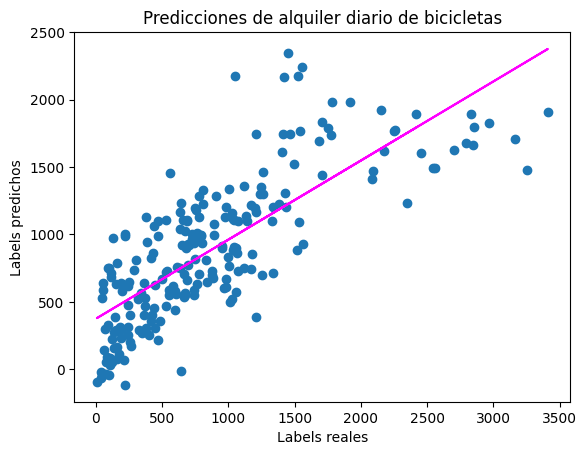

In [13]:
plt.scatter(y_test, predictions)
plt.xlabel('Labels reales')
plt.ylabel('Labels predichos')
plt.title('Predicciones de alquiler diario de bicicletas')

# Superponer la línea de tendencia
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='magenta')
plt.show()

Hay una tendencia diagonal clara, y los puntos siguen en general el camino de la línea, pero con bastante dispersión.

Esa diferencia entre el valor predicho y el observado son los **residuales** del modelo. Evaluados sobre los datos de validación, indican el nivel de error esperado cuando el modelo se use con datos nuevos.

Los residuales se cuantifican con métricas. Usaremos cuatro:

| Métrica | Qué es |
|---|---|
| **MAE** (error absoluto medio) | Media de las diferencias en valor absoluto. Está en las unidades del label |
| **MSE** (error cuadrático medio) | Media de las diferencias al cuadrado. Métrica relativa: cuanto menor, mejor |
| **RMSE** (raíz del ECM) | Raíz cuadrada del MSE. Vuelve a las unidades del label (nº de alquileres) |
| **R²** (coeficiente de determinación) | Cuánta varianza explica el modelo. Cuanto más cerca de 1, mejor |

> **Nota**: el ejercicio original del curso solo calcula MSE, RMSE y R². Añadimos **MAE** porque es una de las métricas pedidas en los entregables del curso.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f'MAE : {mae:.4f}')
print(f'MSE : {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2  : {r2:.4f}')

# Guardar para comparar con los modelos de los siguientes cuadernos
baseline = {'modelo': 'LinearRegression (baseline)', 'MAE': mae, 'RMSE': rmse, 'R2': r2}
baseline

MAE : 322.9976
MSE : 201972.5595
RMSE: 449.4136
R2  : 0.6040


{'modelo': 'LinearRegression (baseline)',
 'MAE': 322.997629189842,
 'RMSE': np.float64(449.4135728595167),
 'R2': 0.6040454736919185}

## Resumen

Exploramos los datos y ajustamos un modelo de regresión base. Tiene *algo* de capacidad predictiva, pero se puede mejorar bastante.

**Estas cifras son el baseline.** En el cuaderno `02-modelos-regresion.ipynb` probamos otros algoritmos para superarlas.